In [22]:
import pandas as pd

file_path = "../chapter04/data/btc_usdt_1d.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["timestamp"],
    index_col="timestamp",
)

df = df.sort_index()

print(df.head())
print(df.tail())

                               open      high       low     close       volume
timestamp                                                                     
2025-08-28 00:00:00+00:00  111254.1  113484.9  110869.6  112564.0  5118.996882
2025-08-29 00:00:00+00:00  112564.1  112642.0  107474.9  108385.7  7323.836956
2025-08-30 00:00:00+00:00  108385.8  108922.9  107343.7  108815.0  4987.664210
2025-08-31 00:00:00+00:00  108815.1  109486.0  108064.9  108248.3  2305.232282
2025-09-01 00:00:00+00:00  108248.0  109911.0  107250.0  109235.9  4341.712476
                              open     high      low    close       volume
timestamp                                                                 
2026-06-19 00:00:00+00:00  62953.3  63664.0  62310.1  63541.0  5700.907189
2026-06-20 00:00:00+00:00  63541.0  64384.5  63200.0  64300.0  7039.788795
2026-06-21 00:00:00+00:00  64300.1  64594.0  63262.0  63313.0  6447.301976
2026-06-22 00:00:00+00:00  63313.1  65629.5  63313.1  64027.6  6066.3150

In [23]:
required_columns = {"open", "high", "low", "close", "volume"}
missing_columns = required_columns - set(df.columns)

print("缺失字段：", missing_columns)

缺失字段： set()


In [24]:
df["ma20"] = df["close"].rolling(window=20).mean()
df["ma60"] = df["close"].rolling(window=60).mean()

print(df[["close", "ma20", "ma60"]].tail())

                             close       ma20          ma60
timestamp                                                  
2026-06-19 00:00:00+00:00  63541.0  64594.785  73490.520000
2026-06-20 00:00:00+00:00  64300.0  64125.705  73290.025000
2026-06-21 00:00:00+00:00  63313.0  63720.605  73042.190000
2026-06-22 00:00:00+00:00  64027.6  63584.110  72805.141667
2026-06-23 00:00:00+00:00  63019.9  63527.790  72565.248333


In [25]:
df["signal"] = df["ma20"] > df["ma60"]

print(df[["close", "ma20", "ma60", "signal"]].tail())

                             close       ma20          ma60  signal
timestamp                                                          
2026-06-19 00:00:00+00:00  63541.0  64594.785  73490.520000   False
2026-06-20 00:00:00+00:00  64300.0  64125.705  73290.025000   False
2026-06-21 00:00:00+00:00  63313.0  63720.605  73042.190000   False
2026-06-22 00:00:00+00:00  64027.6  63584.110  72805.141667   False
2026-06-23 00:00:00+00:00  63019.9  63527.790  72565.248333   False


In [26]:
df["position"] = df["signal"].shift(
    1,
    fill_value=False,
)

print(df[["signal", "position"]].tail())

                           signal  position
timestamp                                  
2026-06-19 00:00:00+00:00   False     False
2026-06-20 00:00:00+00:00   False     False
2026-06-21 00:00:00+00:00   False     False
2026-06-22 00:00:00+00:00   False     False
2026-06-23 00:00:00+00:00   False     False


In [27]:
previous_signal = df["signal"].shift(
    1,
    fill_value=False,
)

In [28]:
df["buy_signal"] = (~previous_signal) & df["signal"]

In [29]:
df["sell_signal"] = previous_signal & (~df["signal"])

In [30]:
buy_count = df["buy_signal"].sum()
sell_count = df["sell_signal"].sum()

print(f"买入信号数量：{buy_count}")
print(f"卖出信号数量：{sell_count}")

买入信号数量：3
卖出信号数量：3


In [31]:
print(df.loc[df["buy_signal"], ["close", "ma20", "ma60"]].tail())

                             close       ma20          ma60
timestamp                                                  
2026-01-12 00:00:00+00:00  91304.0  89800.230  89765.868333
2026-03-29 00:00:00+00:00  66017.2  70164.615  69922.885000
2026-04-10 00:00:00+00:00  72957.4  68911.140  68829.426667


In [32]:
print(df.loc[df["sell_signal"], ["close", "ma20", "ma60"]].tail())

                             close       ma20          ma60
timestamp                                                  
2026-02-01 00:00:00+00:00  76978.0  89472.030  89505.353333
2026-04-06 00:00:00+00:00  68841.0  68555.225  68706.203333
2026-06-02 00:00:00+00:00  66757.5  75736.075  76117.295000


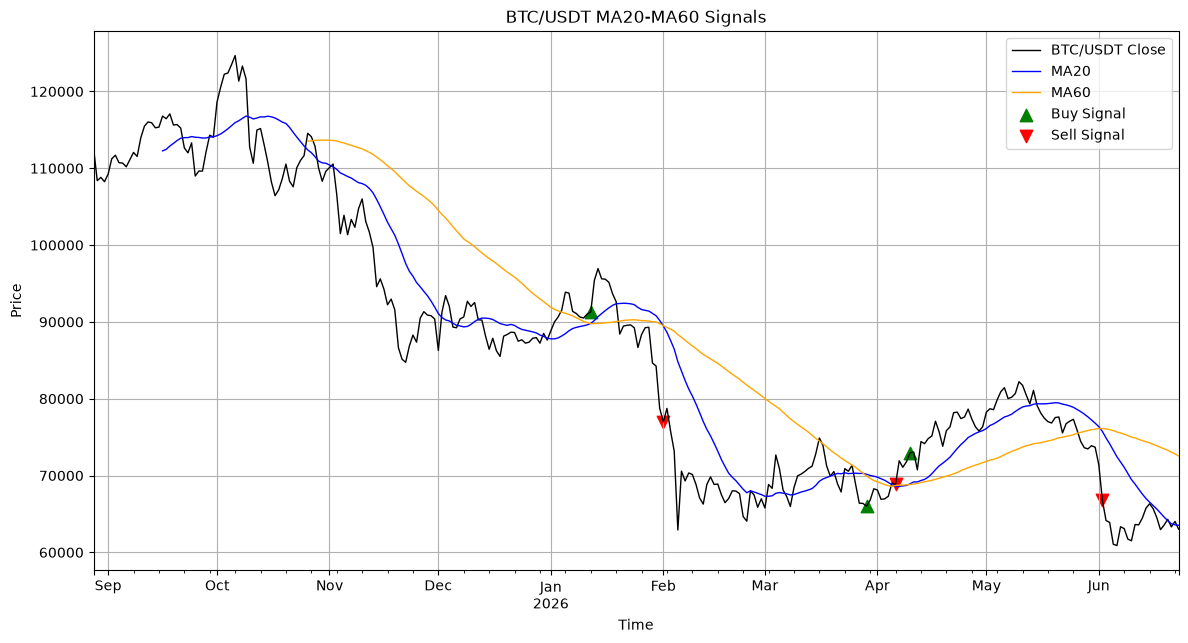

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(14, 7),
)

df["close"].plot(
    ax=ax,
    label="BTC/USDT Close",
    color="black",
    linewidth=1,
)

df["ma20"].plot(
    ax=ax,
    label="MA20",
    color="blue",
    linewidth=1,
)

df["ma60"].plot(
    ax=ax,
    label="MA60",
    color="orange",
    linewidth=1,
)

ax.scatter(
    df.index[df["buy_signal"]],
    df.loc[df["buy_signal"], "close"],
    marker="^",
    color="green",
    s=80,
    label="Buy Signal",
)

ax.scatter(
    df.index[df["sell_signal"]],
    df.loc[df["sell_signal"], "close"],
    marker="v",
    color="red",
    s=80,
    label="Sell Signal",
)

ax.set_title("BTC/USDT MA20-MA60 Signals")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.grid(True)
ax.legend()

plt.show()

In [34]:
df["trend_up"] = df["ma20"] > df["ma60"]

print(df[["close", "ma20", "ma60", "trend_up"]].tail())

                             close       ma20          ma60  trend_up
timestamp                                                            
2026-06-19 00:00:00+00:00  63541.0  64594.785  73490.520000     False
2026-06-20 00:00:00+00:00  64300.0  64125.705  73290.025000     False
2026-06-21 00:00:00+00:00  63313.0  63720.605  73042.190000     False
2026-06-22 00:00:00+00:00  64027.6  63584.110  72805.141667     False
2026-06-23 00:00:00+00:00  63019.9  63527.790  72565.248333     False


In [35]:
df["position"] = df["trend_up"].shift(
    1,
    fill_value=False,
)

print(df[["trend_up", "position"]].tail())

                           trend_up  position
timestamp                                    
2026-06-19 00:00:00+00:00     False     False
2026-06-20 00:00:00+00:00     False     False
2026-06-21 00:00:00+00:00     False     False
2026-06-22 00:00:00+00:00     False     False
2026-06-23 00:00:00+00:00     False     False


In [36]:
previous_ma20 = df["ma20"].shift(1)
previous_ma60 = df["ma60"].shift(1)

In [37]:
df["buy_signal"] = (
    (previous_ma20 <= previous_ma60)
    & (df["ma20"] > df["ma60"])
)

In [38]:
df["sell_signal"] = (
    (previous_ma20 >= previous_ma60)
    & (df["ma20"] < df["ma60"])
)

In [39]:
buy_count = df["buy_signal"].sum()
sell_count = df["sell_signal"].sum()

print(f"买入信号数量：{buy_count}")
print(f"卖出信号数量：{sell_count}")

买入信号数量：3
卖出信号数量：3


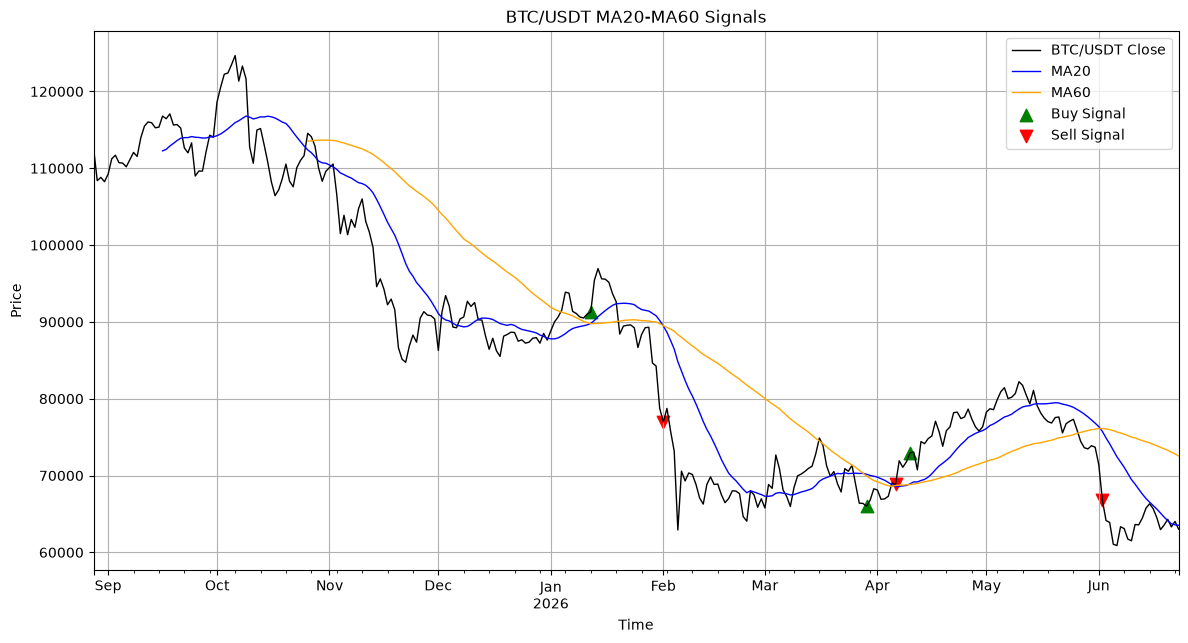

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(14, 7),
)

df["close"].plot(
    ax=ax,
    label="BTC/USDT Close",
    color="black",
    linewidth=1,
)

df["ma20"].plot(
    ax=ax,
    label="MA20",
    color="blue",
    linewidth=1,
)

df["ma60"].plot(
    ax=ax,
    label="MA60",
    color="orange",
    linewidth=1,
)

ax.scatter(
    df.index[df["buy_signal"]],
    df.loc[df["buy_signal"], "close"],
    marker="^",
    color="green",
    s=80,
    label="Buy Signal",
)

ax.scatter(
    df.index[df["sell_signal"]],
    df.loc[df["sell_signal"], "close"],
    marker="v",
    color="red",
    s=80,
    label="Sell Signal",
)

ax.set_title("BTC/USDT MA20-MA60 Signals")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.grid(True)
ax.legend()

plt.show()